<a href="https://colab.research.google.com/github/marcusr2ML/LSTM_stock_prediction/blob/main/BdG_auto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BdG Hamiltonian shape: (3200, 3200)


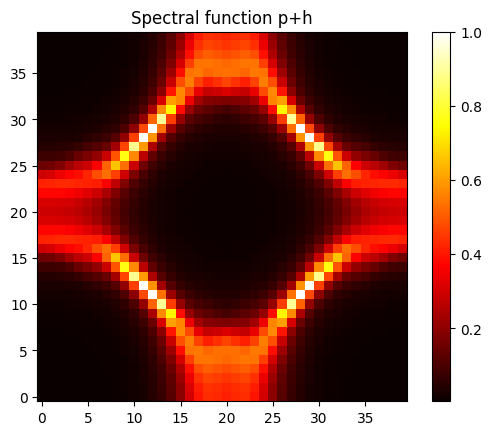

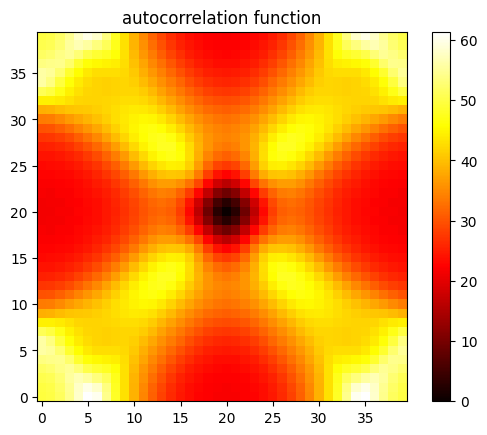

Top 5 values in Q1:

1: value = 59.867640, location = (np.int64(39), np.int64(35))
2: value = 58.073555, location = (np.int64(39), np.int64(34))
3: value = 57.960301, location = (np.int64(39), np.int64(36))
4: value = 56.705591, location = (np.int64(38), np.int64(36))
5: value = 55.416753, location = (np.int64(38), np.int64(35))
(np.float64(50.46047566015894), np.float64(51.51006258305279)) 


In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.linalg as la
import matplotlib.pyplot as plt

# ---------------------------
# Parameters
# ---------------------------
def parameters():
    N = 40         # lattice size
    NN = 2 * N**2   # number of solutions (full Hamiltonian)
    delta_o = 0.06  # gap sets the scale
    bc = 1          # boundary conditions PBC here
    tt = [-0.16235, 0.25, -0.031863, 0.016487, 0.0076112, 0]
    #First term mu, the rest are hoping parameters
    return  N, NN,  tt, delta_o, bc

# ---------------------------
# Kronecker helper
# ---------------------------
def kron3(x, y, z):
    """
    MATLAB faithful kron3(x,y,z) = kron(x, kron(y, z))
    Dense inputs return dense, sparse inputs return sparse.
    """
    # Determine if any input is sparse
    if sp.issparse(x) or sp.issparse(y) or sp.issparse(z):
        return sp.kron(x, sp.kron(y, z, format='csr'), format='csr')
    else:
        return np.kron(x, np.kron(y, z))

# ---------------------------
# Build lattice and SC order
# ---------------------------
def build_SC(N, r1=1, r2=2):
    vector = np.zeros((N,N))
    for j in range(N):
        vector[:, j] = j - 0.5*(N-1)
    S_pdw = np.cos(vector * np.pi / 4)
    S = S_pdw + r1/r2
    ## Another potential pitfall is accidently adding 2*S_pdw to this result
    return S

# ---------------------------
# Build BdG Hamiltonian
# ---------------------------

def build_BdG(S, tt, delta_o, N, bc):
    # vectorized build, speeds up computation massively
    # Pauli matrices
    sz = np.array([[1,0],[0,-1]])

    # ---------------------------
    # Nearest-neighbor hopping
    # ---------------------------
    t0 = sp.diags(np.ones(N))
    t1 = sp.diags(np.ones(N-1), 1) + sp.diags(np.ones(N-1), -1)
    t1 = t1.tolil()
    t1[0,N-1] = np.conj(bc)
    t1[N-1,0] = bc
    t1 = t1.tocsr()

    # Antisymmetric dform
    dform = 0.5 * (sp.kron(t1, t0) - sp.kron(t0, t1))

    # ---------------------------
    # SC order parameter (ant commutator)
    # ---------------------------
    S_diag = sp.diags(np.reshape(delta_o * S, (N**2,)))
    S_matrix = S_diag @ dform + dform @ S_diag

    # Full BdG SC block
    S_total = sp.bmat([[None, S_matrix], [S_matrix.getH(), None]], format='csr')

    # ---------------------------
    # Hopping terms
    # ---------------------------
    S_total = S_total - tt[0]*kron3(sz, sp.eye(N), sp.eye(N))
    S_total = S_total - tt[1]*(kron3(sz, t1, sp.eye(N)) + kron3(sz, sp.eye(N), t1))
    S_total = S_total - tt[2]*kron3(sz, t1, t1)

    # ---------------------------
    # Next-nearest / next-next-nearest hopping
    # ---------------------------
    tt1 = sp.diags(np.ones(N-2), 2) + sp.diags(np.ones(N-2), -2)
    tt1 = tt1.tolil()
    tt1[0,N-2] = np.conj(bc); tt1[N-2,0] = bc
    tt1[1,N-1] = np.conj(bc); tt1[N-1,1] = bc
    tt1 = tt1.tocsr()

    S_total = S_total - tt[3]*(kron3(sz, tt1, sp.eye(N)) + kron3(sz, sp.eye(N), tt1))
    S_total = S_total - tt[4]*(kron3(sz, tt1, t1) + kron3(sz, t1, tt1))
    S_total = S_total - tt[5]*kron3(sz, tt1, tt1)

    return S_total

# ---------------------------
# Spectral function
# ---------------------------
def spec_kw_fft_ph(w, V, E, ee):

    N = int(np.sqrt(V.shape[0] // 2))
    l = len(E)

    # Split u/v like mat2cell
    u = V[:N**2, :]
    v = V[N**2:, :]

    # Reshape to (N,N,l), column-major like MATLAB
    u = u.reshape((N, N, l), order='F')
    v = v.reshape((N, N, l), order='F')

    # Lorentzian
    L1 = ee / ((w - E)**2 + ee**2) / np.pi
    L2 = ee / ((w + E)**2 + ee**2) / np.pi

    # FFT first
    u_fft = np.fft.fft2(u, axes=(0,1))
    v_fft = np.fft.fft2(v, axes=(0,1))

    # Absolute squared
    u_fft = np.abs(u_fft)**2
    v_fft = np.abs(v_fft)**2

    # Flatten to (N^2,l)
    u_fft = u_fft.reshape((N**2, l), order='F')
    v_fft = v_fft.reshape((N**2, l), order='F')

    # Apply Lorentzian weights and reshape back
    h = (u_fft @ L1).reshape((N, N), order='F')
    p = (v_fft @ L2).reshape((N, N), order='F')

    # Normalize by peak of p+h -- was not needed in the end
    # I did this incase I needed to aska  harder question
    peak = np.max(p + h)
    p = np.fft.fftshift(p / peak)
    h = np.fft.fftshift(h / peak)

    return p, h


def compute_g_qw(Akw, q0=4, hard_cut=False):
    #autocorrelation

    A_fft = np.fft.fft2(Akw)
    power = A_fft * np.conj(A_fft)
    g_qw = np.fft.ifft2(power).real
    g_qw = np.fft.fftshift(g_qw)


    N = g_qw.shape[0]

    ## I added a mask to suppress weight at the gamma point. I should have
    ## built this into the background.
    x = np.arange(N) - N//2
    y = np.arange(N) - N//2
    QX, QY = np.meshgrid(x, y, indexing='ij')
    R = np.sqrt(QX**2 + QY**2)

    if hard_cut:
        mask = (R > q0).astype(float)
    else:
        mask = 1 - np.exp(-(R**2) / (2 * q0**2))

    g_qw *= mask

    return g_qw



# ---------------------------
# Main routine
# ---------------------------


if __name__ == "__main__":
    N, NN, tt, delta_o, bc = parameters()

    # Build SC
    S = build_SC(N)

    # Build Hamiltonian
    H = build_BdG(S, tt, delta_o, N, bc)
    print("BdG Hamiltonian shape:", H.shape)


    H_dense = H.toarray()  # convert sparse -> dense
    E, V = la.eigh(H_dense)  # full diagonalization


    # Sort eigenvalues
    idx = np.argsort(E)
    E = E[idx]
    V = V[:, idx]

    # Compute spectral function
    ee = 0.075
    A,B = spec_kw_fft_ph(0, V, E, ee)
    A = (A+B).T  #This transpose makes the "electron pockets" align near ky=0

    # Plot spectral function
    plt.figure()
    plt.imshow(A, origin='lower', cmap='hot')
    plt.colorbar()
    plt.title('Spectral function p+h')
    plt.show()


    g = compute_g_qw(A)

    # Plot JDOS
    plt.figure()
    plt.imshow(g, origin='lower', cmap='hot')
    plt.colorbar()
    plt.title('autocorrelation function')
    plt.show()



    # First quadrant (upper-right after fftshift)
    q1 = g[N//2:, N//2:]

    # Flatten and get top 5 indices
    flat = q1.flatten()
    top_k = 5

    # Indices of top 5 values (unsorted)
    idxs = np.argpartition(flat, -top_k)[-top_k:]

    # Sort them by value (descending)
    idxs = idxs[np.argsort(-flat[idxs])]

    print("Top 5 values in Q1:\n")

    #making sure they are unique magnitudes
    for i, idx in enumerate(idxs):
        val = flat[idx]

        # Convert flat index â†’ 2D local index
        idx_local = np.unravel_index(idx, q1.shape)

        # Convert to global index
        idx_global = (idx_local[0] + N//2, idx_local[1] + N//2)

        print(f"{i+1}: value = {val:.6f}, location = {idx_global}")
    print(f"{g[38,0],g[0,38]} ")
